Loading Reuters Data...
2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
Data Loaded. Training Shape: (8982, 150)

Training Baseline Model...
Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.3826 - loss: 2.5325 - val_accuracy: 0.4808 - val_loss: 2.0641
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.4997 - loss: 1.9348 - val_accuracy: 0.5192 - val_loss: 1.7954
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 145ms/step - accuracy: 0.5528 - loss: 1.7159 - val_accuracy: 0.5598 - val_loss: 1.6876
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.5773 - loss: 1.6272 - val_accuracy: 0.5570 - val_loss: 1.6588
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - accuracy: 0.6107 - loss: 1.5411 - val_accuracy: 0.5915 - val_loss: 1.6371
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 125ms/step - accuracy: 0.6313 - loss: 1.4711 - val_accuracy: 0.6049 - val_loss: 1.5972
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 129ms/step - accuracy: 0.673

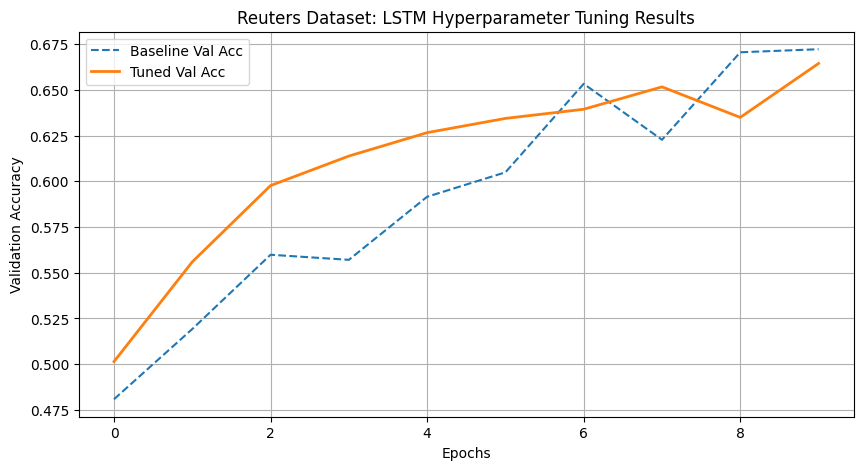

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D, Dropout
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PREPROCESSING ---
# Only keep the top 10,000 most frequently occurring words
MAX_WORDS = 10000
# Reuters articles are shorter on average than IMDB reviews; 150 is a good cutoff
MAX_LEN = 150
# Number of classes (topics) in the dataset
NUM_CLASSES = 46

print("Loading Reuters Data...")
# Load the dataset
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=MAX_WORDS)

# Pad sequences (ensure all inputs are same length)
X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

# For multi-class, we use categorical crossentropy, so labels must be one-hot encoded
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print(f"Data Loaded. Training Shape: {X_train.shape}")

# --- 2. BASELINE MODEL (Simple LSTM) ---
def build_baseline_model():
    model = Sequential()
    model.add(Embedding(input_dim=MAX_WORDS, output_dim=64)) # Input length inferred
    model.add(LSTM(64)) # Simple LSTM
    model.add(Dense(NUM_CLASSES, activation='softmax')) # Softmax for multi-class
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

print("\nTraining Baseline Model...")
baseline = build_baseline_model()
hist_base = baseline.fit(X_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=1)

# --- 3. TUNED MODEL (Hyperparameter Optimization) ---
# Improvements for Multi-class:
# 1. Embedding: Increased to 256 for better semantic capture.
# 2. Regularization: SpatialDropout1D and Dropout added to prevent overfitting.
# 3. Capacity: Larger LSTM layer (128 units) to handle 46 distinct classes.
def build_tuned_model():
    model = Sequential()
    model.add(Embedding(input_dim=MAX_WORDS, output_dim=256))
    model.add(SpatialDropout1D(0.3))
    model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(128, activation='relu')) # Added an extra dense layer
    model.add(Dropout(0.3))
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

print("\nTraining Tuned Model...")
tuned = build_tuned_model()
hist_tuned = tuned.fit(X_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=1)

# --- 4. COMPARISON & RESULTS ---
score_base = baseline.evaluate(X_test, y_test_cat, verbose=0)
score_tuned = tuned.evaluate(X_test, y_test_cat, verbose=0)

print("-" * 40)
print(f"Baseline LSTM Accuracy: {score_base[1]*100:.2f}%")
print(f"Tuned LSTM Accuracy:    {score_tuned[1]*100:.2f}%")
print("-" * 40)

# Plotting Improvement
plt.figure(figsize=(10, 5))
plt.plot(hist_base.history['val_accuracy'], label='Baseline Val Acc', linestyle='--')
plt.plot(hist_tuned.history['val_accuracy'], label='Tuned Val Acc', linewidth=2)
plt.title('Reuters Dataset: LSTM Hyperparameter Tuning Results')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()